# 🏪 Rossmann Sales Analysis

## 📌 Proje Amacı

Bu projede Rossmann mağaza satış verileri analiz edilmiştir.

Amaç:
- Satışları etkileyen faktörleri incelemek
- Promo ve tatil etkisini analiz etmek
- Zaman içindeki satış trendlerini görmek
- Mağazaları performanslarına göre gruplandırmak

## Kullanılan Teknolojiler

- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn

## Analiz Adımları

1. Veri yükleme ve temizleme
2. Keşifsel veri analizi (EDA)
3. Zaman serisi analizi
4. Store performans analizi
5. Clustering

# 1. Veri Yükleme

Train ve Store veri setleri okunarak birleştirilmiştir.

In [9]:
import pandas as pd

train = pd.read_csv("train.csv")
store = pd.read_csv("store.csv")

print(train.shape)
print(store.shape)

train.head()

(1017209, 9)
(1115, 10)


C:\Users\HP\AppData\Local\Temp\ipykernel_6252\2434888039.py:3: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("train.csv")


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


# 2. Veri Kontrolü

Veri yapısı, eksik değerler ve değişken tipleri incelenmiştir.

In [11]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


In [13]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [15]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


In [17]:
train.isnull().sum()

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

In [19]:
train.describe()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00


In [21]:
train["Date"] = pd.to_datetime(train["Date"])

train["Year"] = train["Date"].dt.year
train["Month"] = train["Date"].dt.month
train["Day"] = train["Date"].dt.day

train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Year,Month,Day
0,1,5,2015-07-31,5263,555,1,1,0,1,2015,7,31
1,2,5,2015-07-31,6064,625,1,1,0,1,2015,7,31
2,3,5,2015-07-31,8314,821,1,1,0,1,2015,7,31
3,4,5,2015-07-31,13995,1498,1,1,0,1,2015,7,31
4,5,5,2015-07-31,4822,559,1,1,0,1,2015,7,31


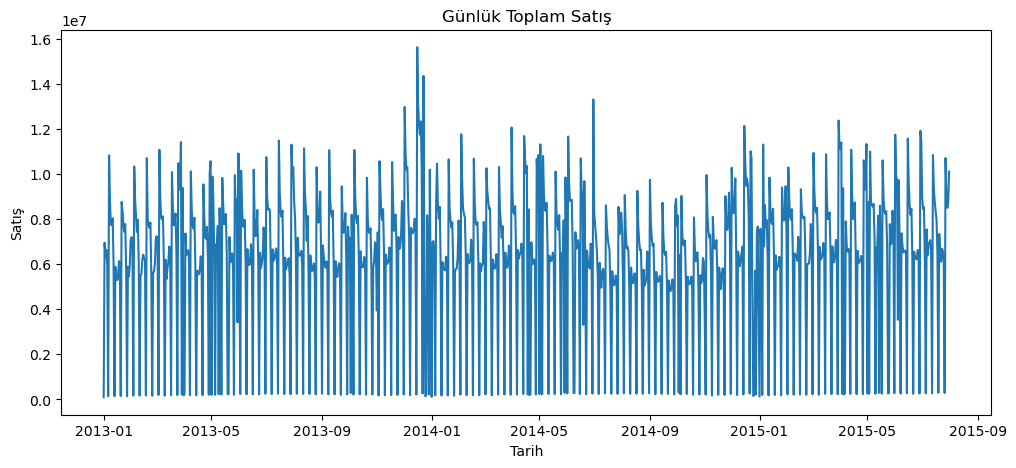

In [23]:
import matplotlib.pyplot as plt

sales_by_date = train.groupby("Date")["Sales"].sum()

plt.figure(figsize=(12,5))
plt.plot(sales_by_date)
plt.title("Günlük Toplam Satış")
plt.xlabel("Tarih")
plt.ylabel("Satış")
plt.show()

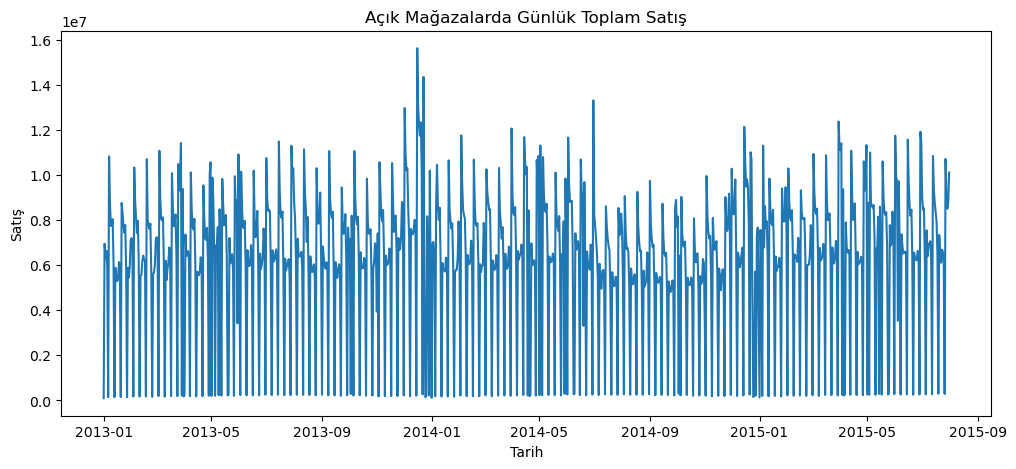

In [25]:
open_sales = train[train["Open"] == 1]

sales_by_date = open_sales.groupby("Date")["Sales"].sum()

plt.figure(figsize=(12,5))
plt.plot(sales_by_date)
plt.title("Açık Mağazalarda Günlük Toplam Satış")
plt.xlabel("Tarih")
plt.ylabel("Satış")
plt.show()

# 3. Promo Etkisinin Analizi

Kampanya dönemlerinde satışların nasıl değiştiği incelenmiştir.

In [27]:
promo_sales = train.groupby("Promo")["Sales"].mean()

promo_sales

Promo
0    4406.050805
1    7991.152046
Name: Sales, dtype: float64

In [37]:
df = pd.read_csv("train.csv", low_memory=False)

In [41]:
df = pd.read_csv("train.csv", dtype={"StateHoliday": str})

In [43]:
df = pd.read_csv("train.csv", low_memory=False)

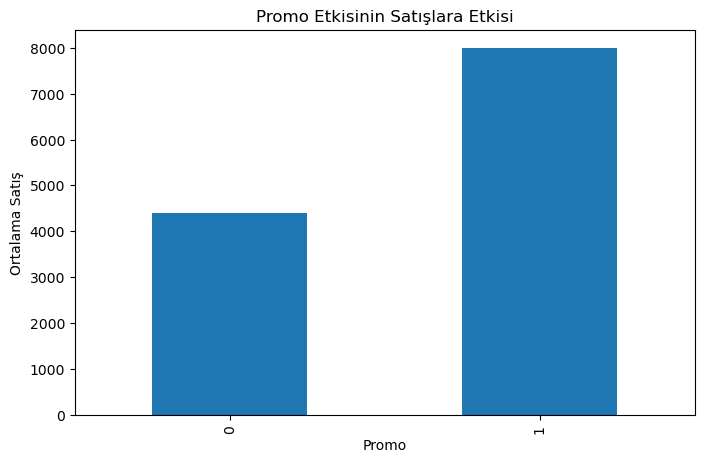

In [105]:
promo_sales.plot(kind="bar", figsize=(8,5))
plt.title("Promo Etkisinin Satışlara Etkisi")
plt.xlabel("Promo")
plt.ylabel("Ortalama Satış")
plt.show()

### Yorum

Promo uygulanan günlerde ortalama satışların daha yüksek olduğu görülmektedir.
Bu durum kampanyaların müşteri davranışı üzerinde etkili olduğunu göstermektedir.

In [45]:
df["StateHoliday"].unique()

array(['0', 'a', 'b', 'c'], dtype=object)

In [47]:
df["StateHoliday"] = df["StateHoliday"].astype(str)
df["StateHoliday"] = df["StateHoliday"].replace("0", "None")

In [49]:
import pandas as pd

df = pd.read_csv(
    "train.csv",
    dtype={"StateHoliday": str},
    low_memory=False
)

# 4. Zaman Serisi Analizi

Satışların zaman içerisindeki değişimi incelenmiştir.

In [51]:
df["Date"] = pd.to_datetime(df["Date"])

In [53]:
daily_sales = df.groupby("Date")["Sales"].sum()
daily_sales.head()

Date
2013-01-01      97235
2013-01-02    6949829
2013-01-03    6347820
2013-01-04    6638954
2013-01-05    5951593
Name: Sales, dtype: int64

<Axes: xlabel='Date'>

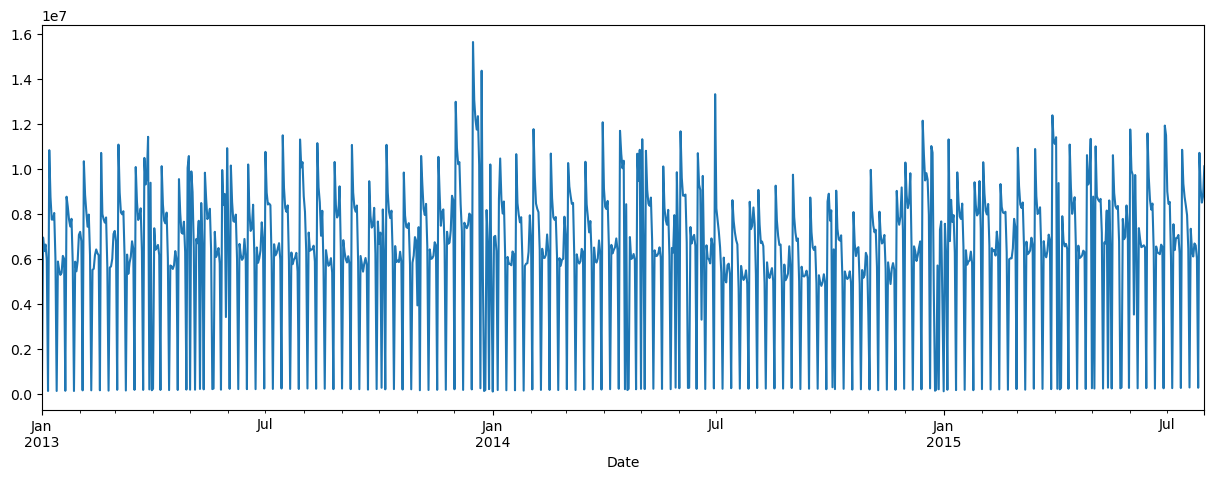

In [55]:
daily_sales.plot(kind="line", figsize=(15,5))

# 5. Mağaza Performans Analizi

Mağazalar toplam ve ortalama satış değerlerine göre değerlendirilmiştir.

In [109]:
store_sales = df.groupby("Store")["Sales"].sum()

top10 = store_sales.sort_values(ascending=False).head(10)

top10

Store
262     19516842
817     17057867
562     16927322
1114    16202585
251     14896870
513     14252406
788     14082141
733     14067158
383     13489879
756     12911782
Name: Sales, dtype: int64

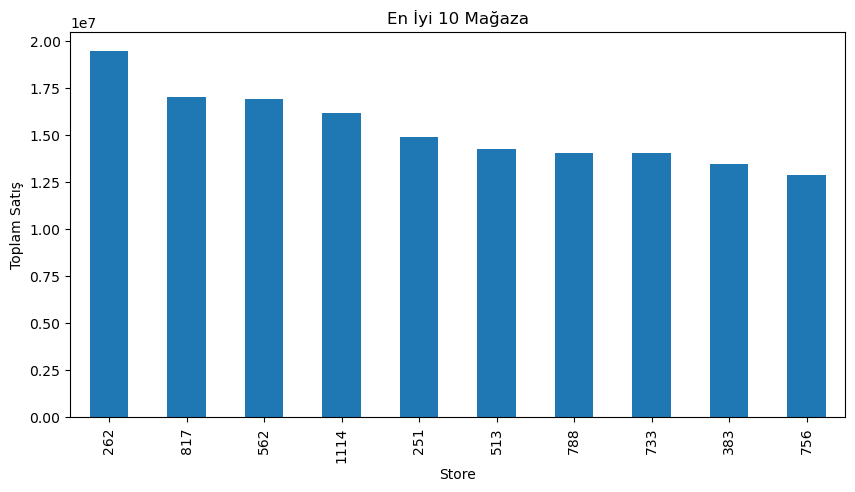

In [112]:
top10.plot(kind="bar", figsize=(10,5))

plt.title("En İyi 10 Mağaza")
plt.xlabel("Store")
plt.ylabel("Toplam Satış")

plt.show()

<Axes: xlabel='Date'>

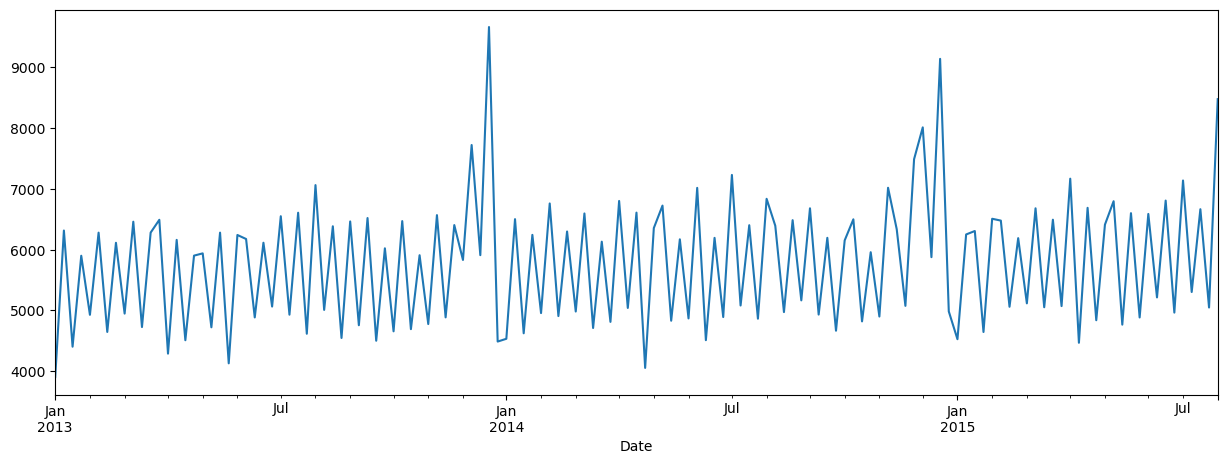

In [57]:
weekly_sales = df.groupby(pd.Grouper(key="Date", freq="W"))["Sales"].mean()
weekly_sales.plot(kind="line", figsize=(15,5))

<Axes: xlabel='Date'>

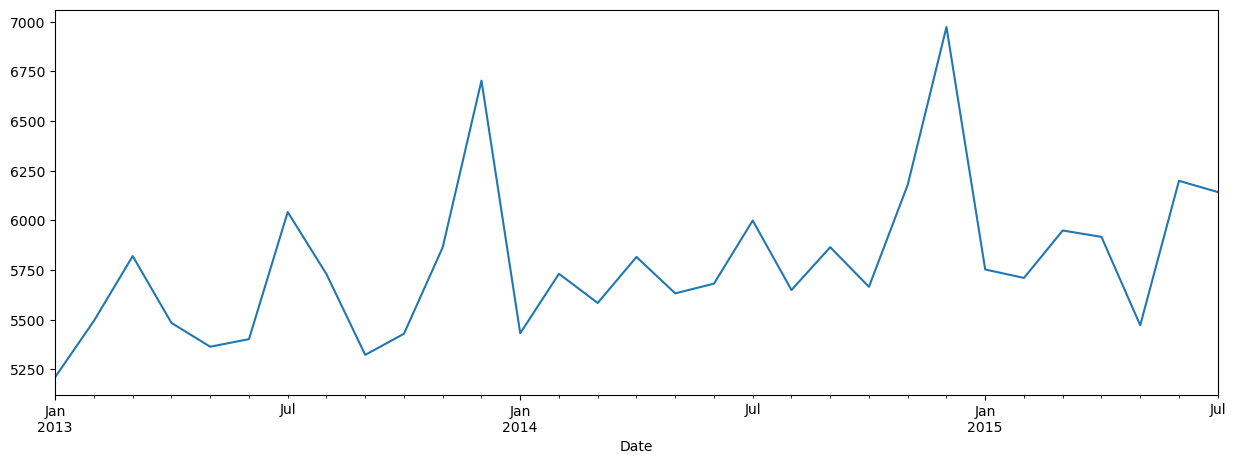

In [61]:
monthly_sales = df.groupby(pd.Grouper(key="Date", freq="ME"))["Sales"].mean()
monthly_sales.plot(figsize=(15,5))

In [63]:
store_sales = df.groupby("Store")["Sales"].sum()
store_sales.head()

Store
1    3716854
2    3883858
3    5408261
4    7556507
5    3642818
Name: Sales, dtype: int64

In [65]:
top10_stores = store_sales.sort_values(ascending=False).head(10)
top10_stores

Store
262     19516842
817     17057867
562     16927322
1114    16202585
251     14896870
513     14252406
788     14082141
733     14067158
383     13489879
756     12911782
Name: Sales, dtype: int64

<Axes: xlabel='Store'>

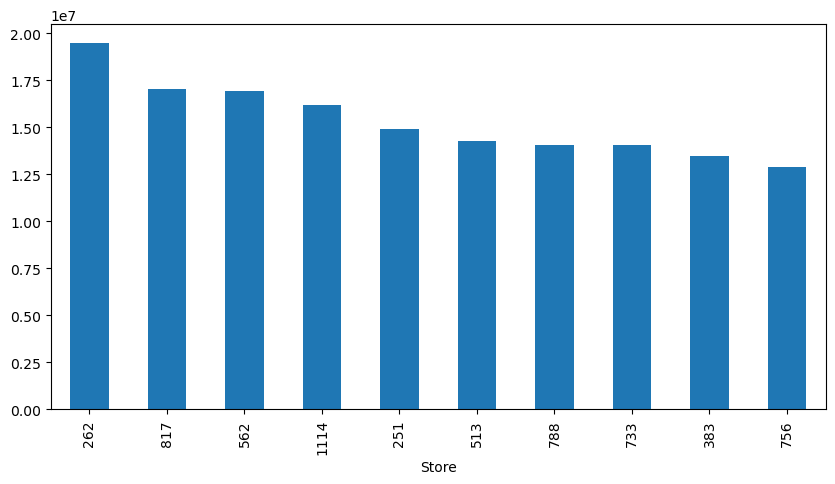

In [67]:
top10_stores.plot(kind="bar", figsize=(10,5))

In [69]:
bottom10_stores = store_sales.sort_values(ascending=True).head(10)
bottom10_stores

Store
307    2114322
543    2179287
198    2268273
208    2302052
263    2306075
841    2318635
879    2340576
254    2341661
186    2353548
972    2402627
Name: Sales, dtype: int64

<Axes: xlabel='Store'>

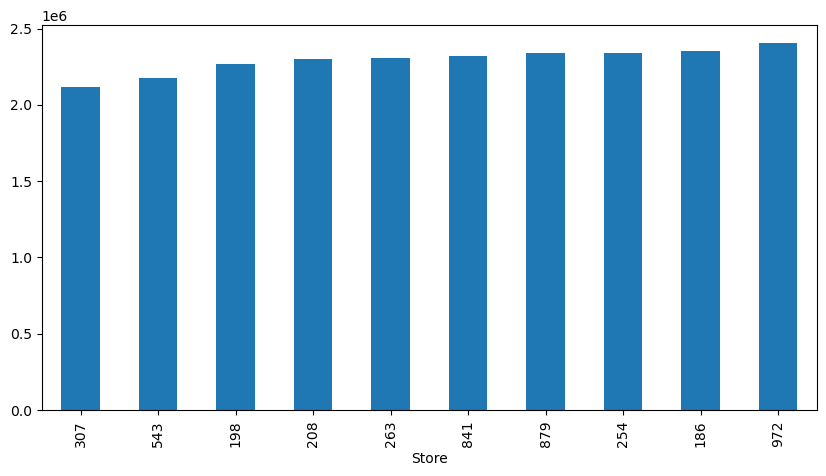

In [71]:
bottom10_stores.plot(kind="bar", figsize=(10,5))

In [76]:
store_avg_sales = df.groupby("Store")["Sales"].mean()

In [78]:
store_avg_sales.sort_values(ascending=False).head(10)

Store
262     20718.515924
817     18108.139066
562     17969.556263
1114    17200.196391
251     15814.087049
842     15242.114776
513     15129.942675
788     14949.194268
733     14933.288747
383     14320.466030
Name: Sales, dtype: float64

In [80]:
df.groupby(["Store", "Promo"])["Sales"].mean().head(10)

Store  Promo
1      0         3198.994845
       1         5152.886111
2      0         2855.058419
       1         6172.816667
3      0         3967.596220
       1         8608.666667
4      0         6568.939863
       1        10370.511111
5      0         2582.271478
       1         5944.266667
Name: Sales, dtype: float64

In [82]:
store_df = df.groupby("Store").agg({
    "Sales": ["mean", "sum"],
    "Customers": "mean",
    "Promo": "mean"
})

store_df.columns = ["Sales_mean", "Sales_sum", "Customers_mean", "Promo_mean"]
store_df.head()

,Sales_mean,Sales_sum,Customers_mean,Promo_mean
Store,,,,
1,3945.704883,3716854,467.646497,0.382166
2,4122.991507,3883858,486.045648,0.382166
3,5741.253715,5408261,620.286624,0.382166
4,8021.769639,7556507,1100.057325,0.382166
5,3867.110403,3642818,444.360934,0.382166


In [84]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(store_df)

In [86]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
store_df["Cluster"] = kmeans.fit_predict(scaled_data)

store_df.head()

,Sales_mean,Sales_sum,Customers_mean,Promo_mean,Cluster
Store,,,,,
1,3945.704883,3716854,467.646497,0.382166,0
2,4122.991507,3883858,486.045648,0.382166,0
3,5741.253715,5408261,620.286624,0.382166,0
4,8021.769639,7556507,1100.057325,0.382166,1
5,3867.110403,3642818,444.360934,0.382166,0


In [88]:
store_df.groupby("Cluster").mean()

,Sales_mean,Sales_sum,Customers_mean,Promo_mean
Cluster,,,,
0,5105.849812,4.809705e+06,546.359867,0.382166
1,9120.763228,8.524331e+06,1120.191542,0.382000
2,5257.890623,3.985481e+06,498.689375,0.377309


In [90]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
components = pca.fit_transform(scaled_data)

store_df["PCA1"] = components[:, 0]
store_df["PCA2"] = components[:, 1]

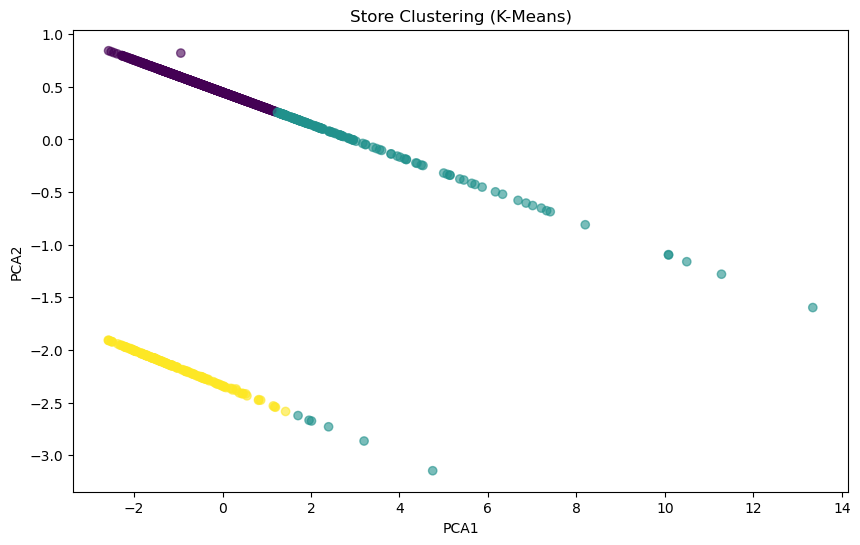

In [96]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(store_df["PCA1"], store_df["PCA2"], c=store_df["Cluster"], alpha=0.6)
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title("Store Clustering (K-Means)")
plt.show()

# 6. Store Clustering

Benzer satış davranışına sahip mağazaları belirlemek için K-Means algoritması kullanılmıştır.

In [115]:
store_cluster = df.groupby("Store").agg({
    "Sales":"mean",
    "Customers":"mean",
    "Promo":"mean"
})

store_cluster.head()

,Sales,Customers,Promo
Store,,,
1,3945.704883,467.646497,0.382166
2,4122.991507,486.045648,0.382166
3,5741.253715,620.286624,0.382166
4,8021.769639,1100.057325,0.382166
5,3867.110403,444.360934,0.382166


# 📌 Sonuç

Bu projede Rossmann mağazalarına ait satış verileri analiz edilmiştir.

Yapılan analizler sonucunda:

- Promo kampanyalarının satışlar üzerinde olumlu etkisi olduğu görülmüştür.
- Satışların zaman içerisinde değişim gösterdiği ve dönemsel hareketler içerdiği gözlemlenmiştir.
- Mağazalar toplam satış ve müşteri performanslarına göre farklı seviyelerde değerlendirilmiştir.
- K-Means clustering yöntemi ile benzer satış davranışına sahip mağazalar gruplandırılmıştır.

Elde edilen bulgular, mağaza performanslarını anlamak, kampanya stratejileri geliştirmek ve gelecekteki satış tahmin modelleri için temel oluşturmaktadır.

Bu proje ile veri temizleme, keşifsel veri analizi, görselleştirme ve makine öğrenmesi öncesi veri hazırlama süreçleri uygulanmıştır.